### Sales Data Analysis

In [1]:
# Imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import calendar

# loading of the clean dataset
df = pd.read_csv(r"C:\Users\Admin\Desktop\Amazon\cleaned_Amazon_data.csv")
print('Loaded dataframe with', df.shape[0], 'rows and', df.shape[1], 'columns')
df.head()

Loaded dataframe with 243 rows and 11 columns


,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10/3/2025,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


In [2]:
# Quick info and column standardization
df.columns = [c.strip() for c in df.columns]
df.info()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           243 non-null    object
 1   Date               243 non-null    object
 2   Product            243 non-null    object
 3   Category           243 non-null    object
 4   Price              243 non-null    int64 
 5   Quantity           243 non-null    int64 
 6   Total Sales        243 non-null    int64 
 7   Customer Name      243 non-null    object
 8   Customer Location  243 non-null    object
 9   Payment Method     243 non-null    object
 10  Status             243 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.0+ KB


,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
89,ORD0095,17-02-25,Smartwatch,Electronics,150,4,600,Chris White,New York,Debit Card,Cancelled
83,ORD0088,6/2/2025,Refrigerator,Home Appliances,1200,2,2400,Chris White,Seattle,Debit Card,Pending
218,ORD0226,5/3/2025,Running Shoes,Footwear,60,4,240,Chris White,Chicago,Amazon Pay,Completed
241,ORD0249,8/3/2025,Smartwatch,Electronics,150,3,450,Emily Johnson,New York,Debit Card,Cancelled
96,ORD0102,28-02-25,Smartphone,Electronics,500,2,1000,David Lee,Boston,PayPal,Pending


In [3]:
#Handle multiple formats like '14-03-25', '10/3/2025', etc.
def parse_date(x):
    if pd.isna(x): 
        return pd.NaT
    x = str(x).strip()
    for fmt in ('%d-%m-%y','%d-%m-%Y','%d/%m/%Y','%d/%m/%y','%Y-%m-%d','%d-%b-%Y','%d-%B-%Y'):
        try:
            return pd.to_datetime(x, format=fmt)
        except Exception:
            pass
    # try pandas flexible parser as fallback
    try:
        return pd.to_datetime(x, dayfirst=True, errors='coerce')
    except Exception:
        return pd.NaT

df['Date_parsed'] = df['Date'].apply(parse_date)
# if parsing failed for some rows, show them
failed = df[df['Date_parsed'].isna()]
print('Failed to parse dates for', len(failed), 'rows')
df['Date'] = df['Date_parsed']
df.drop(columns=['Date_parsed'], inplace=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['MonthName'] = df['Month'].apply(lambda m: calendar.month_name[m] if not pd.isna(m) else None)
df.head()

Failed to parse dates for 0 rows


,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status,Year,Month,Day,MonthName
0,ORD0001,2025-03-14,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled,2025,3,14,March
1,ORD0002,2025-03-20,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending,2025,3,20,March
2,ORD0003,2025-02-15,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled,2025,2,15,February
3,ORD0004,2025-02-19,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending,2025,2,19,February
4,ORD0005,2025-03-10,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending,2025,3,10,March


In [4]:
# Numeric cleaning: Price, Quantity, Total Sales
for col in ['Price','Quantity','Total Sales']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# If Total Sales missing, compute Price * Quantity
if 'Total Sales' in df.columns:
    missing_total = df['Total Sales'].isna().sum()
    print('Missing Total Sales:', missing_total)
    df.loc[df['Total Sales'].isna(), 'Total Sales'] = (df['Price'] * df['Quantity']).loc[df['Total Sales'].isna()]

df['Quantity'] = df['Quantity'].fillna(0).astype(int)
df['Price'] = df['Price'].fillna(0)
df['Total Sales'] = df['Total Sales'].fillna(0)
df.describe().T

Missing Total Sales: 0


,count,mean,min,25%,50%,75%,max,std
Date,243,2025-03-04 08:00:00,2025-02-02 00:00:00,2025-02-18 00:00:00,2025-03-05 00:00:00,2025-03-18 00:00:00,2025-04-02 00:00:00,NaN
Price,243.0,318.909465,15.0,40.0,150.0,500.0,1200.0,356.717913
Quantity,243.0,2.814815,1.0,2.0,3.0,4.0,5.0,1.426819
Total Sales,243.0,855.329218,15.0,100.0,300.0,1200.0,4000.0,1042.969623
Year,243.0,2025.0,2025.0,2025.0,2025.0,2025.0,2025.0,0.0
Month,243.0,2.576132,2.0,2.0,3.0,3.0,4.0,0.542955
Day,243.0,16.127572,1.0,10.0,16.0,23.0,31.0,8.135994


In [5]:
# BASIC KPIs
total_revenue = df['Total Sales'].sum()
total_orders = df['Order ID'].nunique()
average_order_value = total_revenue / total_orders if total_orders else 0

units_per_day = df.groupby('Date')['Quantity'].sum()
avg_units_per_day = units_per_day.mean()
unique_customers = df['Customer Name'].nunique() if 'Customer Name' in df.columns else None
unique_products = df['Product'].nunique() if 'Product' in df.columns else None

cancel_count = df['Status'].str.contains('cancel', case=False, na=False).sum() if 'Status' in df.columns else 0
cancel_rate = cancel_count / total_orders if total_orders else 0

kpis = {
    'Total Revenue': total_revenue,
    'Total Orders': total_orders,
    'Average Order Value (AOV)': average_order_value,
    'Avg Units per Day': avg_units_per_day,
    'Unique Customers': unique_customers,
    'Unique Products': unique_products,
    'Cancel/Return Count': cancel_count,
    'Cancel/Return Rate': cancel_rate
}
kpis

{'Total Revenue': np.int64(207845),
 'Total Orders': 243,
 'Average Order Value (AOV)': np.float64(855.3292181069959),
 'Avg Units per Day': np.float64(11.4),
 'Unique Customers': 10,
 'Unique Products': 10,
 'Cancel/Return Count': np.int64(75),
 'Cancel/Return Rate': np.float64(0.30864197530864196)}

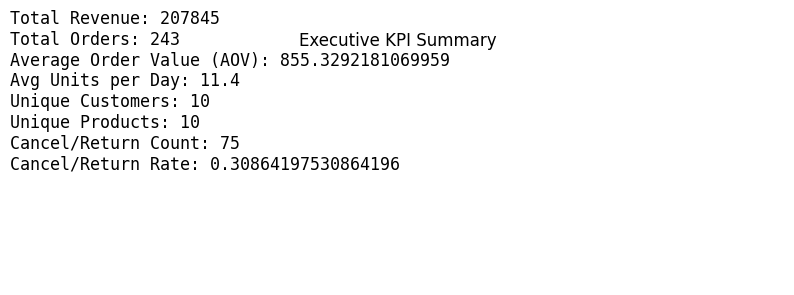

In [6]:
#KPI DASHBOARD
fig, ax = plt.subplots(figsize=(10,3))
ax.axis('off')
kpi_text = '\n'.join([f"{k}: {v if not pd.isna(v) else 'N/A'}" for k,v in kpis.items()])
ax.text(0,0.5, kpi_text, fontsize=12, family='monospace')
plt.title('Executive KPI Summary')
plt.show()

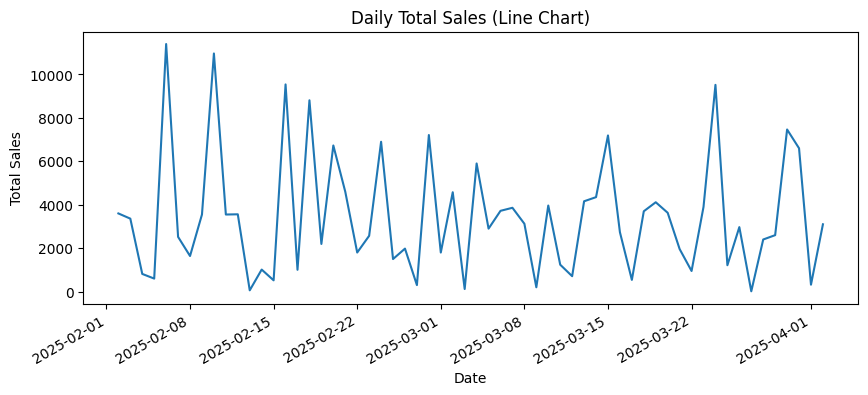

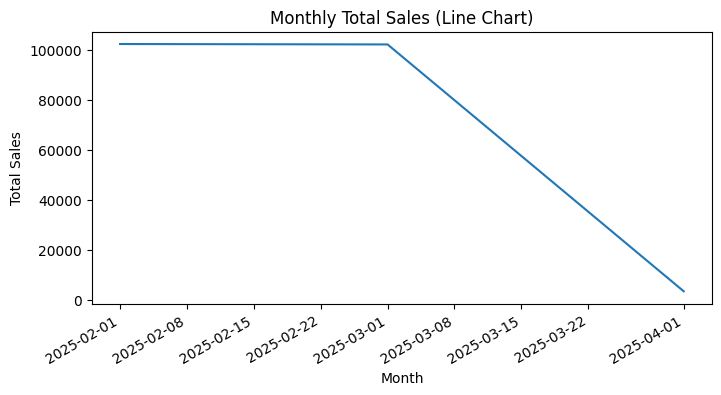

In [7]:
#daily and monthly totals
daily = df.groupby('Date').agg({'Total Sales':'sum','Order ID':'nunique','Quantity':'sum'}).rename(columns={'Order ID':'Orders'})
monthly = df.groupby([df['Date'].dt.to_period('M')]).agg({'Total Sales':'sum','Order ID':'nunique','Quantity':'sum'}).rename(columns={'Order ID':'Orders'})
daily_head = daily.head()
daily_tail = daily.tail()

#daily sales trend (line chart)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(daily.index, daily['Total Sales'])
ax.set_title('Daily Total Sales (Line Chart)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
fig.autofmt_xdate()
plt.show()

#monthly totals
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(monthly.index.to_timestamp(), monthly['Total Sales'])
ax.set_title('Monthly Total Sales (Line Chart)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
fig.autofmt_xdate()
plt.show()

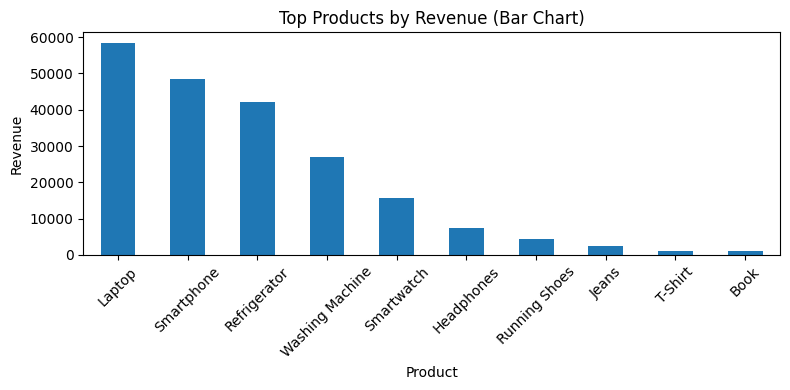

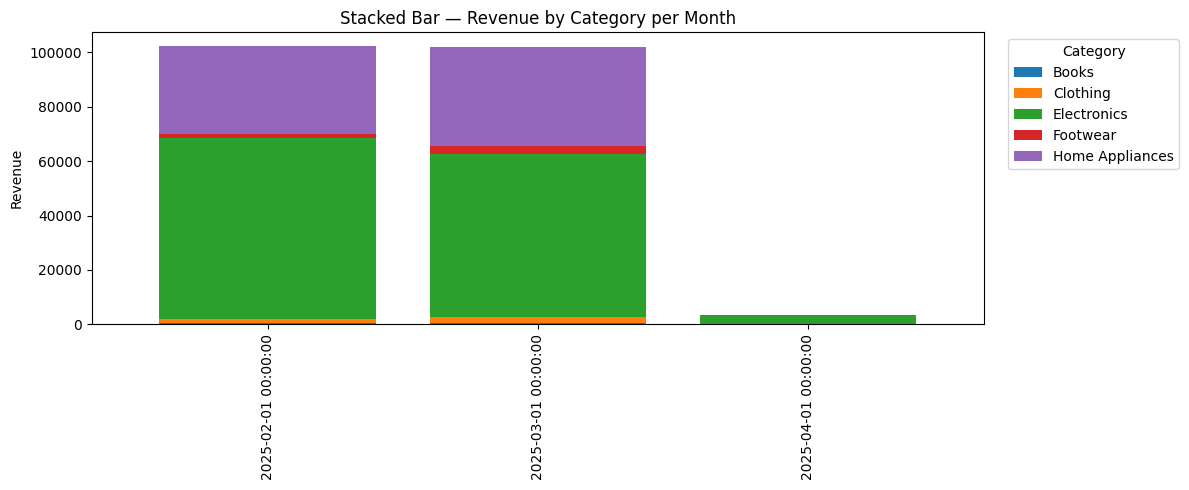

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')              
df['Total Sales'] = pd.to_numeric(df['Total Sales'], errors='coerce') 

df = df.dropna(subset=['Date', 'Total Sales']).reset_index(drop=True)

if 'Product' in df.columns and 'Category' in df.columns:
    rev_by_product = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False)
    rev_by_category = df.groupby('Category')['Total Sales'].sum().sort_values(ascending=False)
    units_by_product = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
    cumrev_by_product = rev_by_product.cumsum()
else:
    rev_by_product = pd.Series(dtype='float64')
    rev_by_category = pd.Series(dtype='float64')
    units_by_product = pd.Series(dtype='float64')
    cumrev_by_product = pd.Series(dtype='float64')

#Top products bar chart
fig, ax = plt.subplots(figsize=(8,4))
topN = 10
rev_by_product.head(topN).plot(kind='bar', ax=ax)
ax.set_title('Top Products by Revenue (Bar Chart)')
ax.set_ylabel('Revenue')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#Stacked bar: revenue by category per month
if 'Category' in df.columns:
    df['month_ts'] = df['Date'].dt.to_period('M').dt.to_timestamp()

    pivot_cat_month = df.pivot_table(
        index='month_ts',
        columns='Category',
        values='Total Sales',
        aggfunc='sum'
    ).fillna(0).sort_index()

    fig, ax = plt.subplots(figsize=(12,5))
    pivot_cat_month.plot(kind='bar', stacked=True, ax=ax, width=0.8)
    ax.set_title('Stacked Bar — Revenue by Category per Month')
    ax.set_ylabel('Revenue')
    ax.set_xlabel('')
    ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

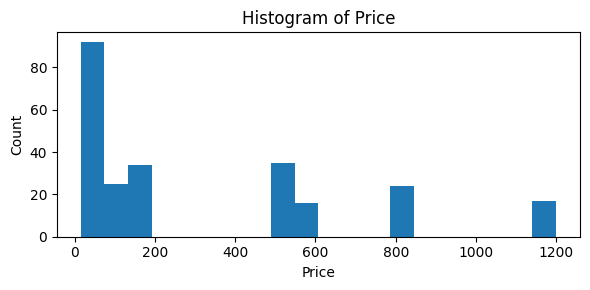

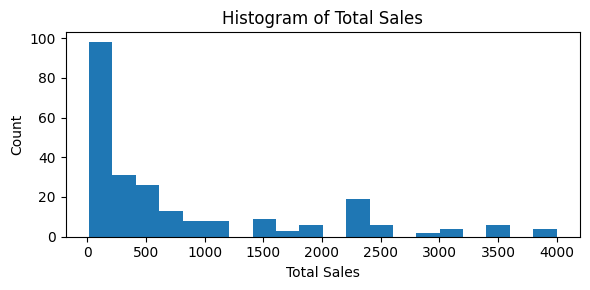

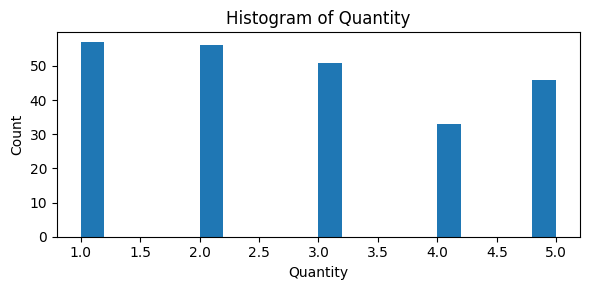

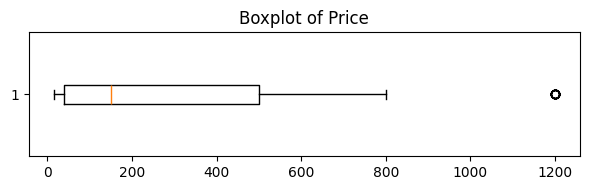

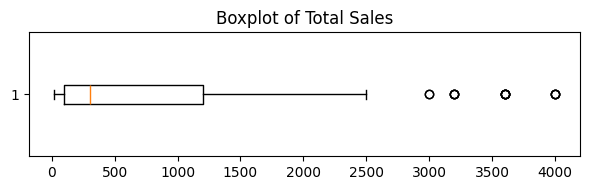

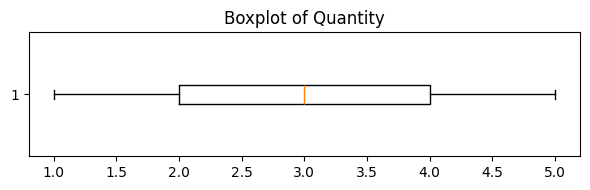

In [16]:
# DISTRIBUTION AND OUTLIERS
# Histogram of Price, Total Sales, Quantity
numeric_cols = ['Price','Total Sales','Quantity']
for col in numeric_cols:
    if col in df.columns:
        fig, ax = plt.subplots(figsize=(6,3))
        ax.hist(df[col].dropna(), bins=20)
        ax.set_title(f'Histogram of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()

# Boxplots
for col in numeric_cols:
    if col in df.columns:
        fig, ax = plt.subplots(figsize=(6,2))
        ax.boxplot(df[col].dropna(), vert=False)
        ax.set_title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()

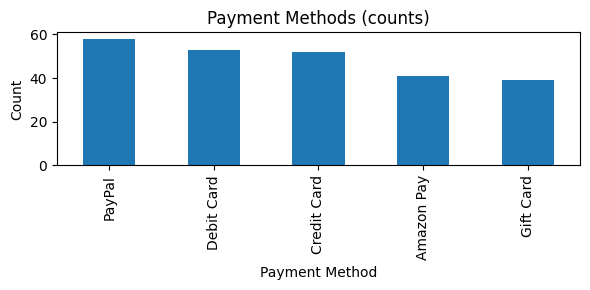

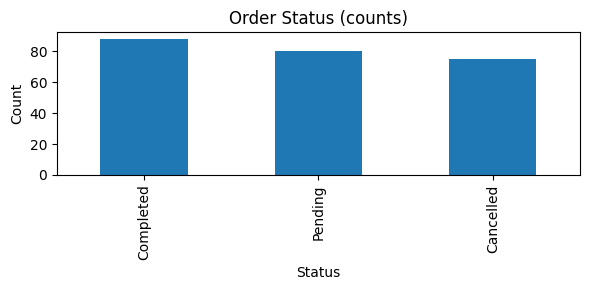

In [17]:
# PAYMENT METHOD & ORDER STATUS ANALYSIS
if 'Payment Method' in df.columns:
    payment_counts = df['Payment Method'].value_counts()
    fig, ax = plt.subplots(figsize=(6,3))
    payment_counts.plot(kind='bar', ax=ax)
    ax.set_title('Payment Methods (counts)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

if 'Status' in df.columns:
    status_counts = df['Status'].value_counts()
    fig, ax = plt.subplots(figsize=(6,3))
    status_counts.plot(kind='bar', ax=ax)
    ax.set_title('Order Status (counts)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

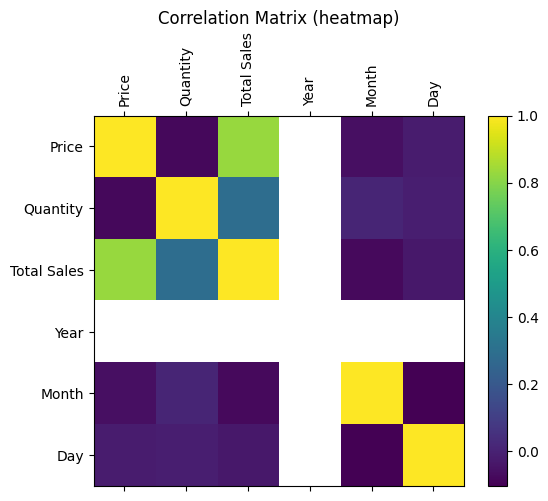

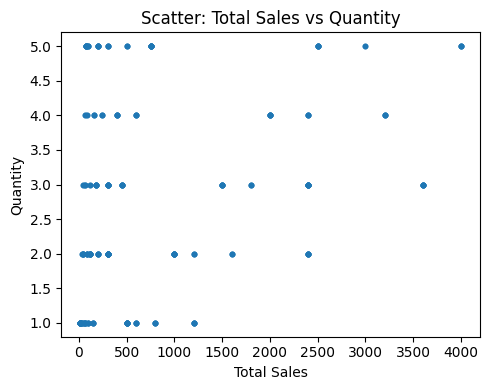

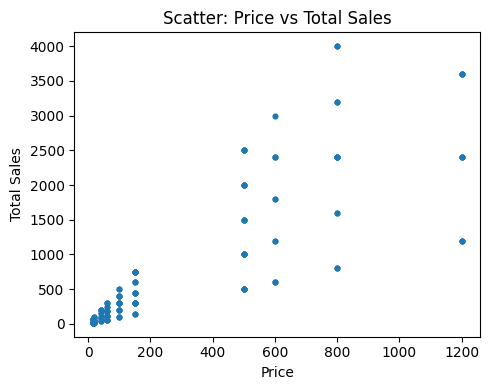

In [11]:
# CORRELATION HEATMAP and Scatter plots
num_df = df.select_dtypes(include=[np.number]).copy()
if not num_df.empty:
    corr = num_df.corr()
    fig, ax = plt.subplots(figsize=(6,5))
    cax = ax.matshow(corr)
    fig.colorbar(cax)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    ax.set_title('Correlation Matrix (heatmap)')
    plt.tight_layout()
    plt.show()

    # Scatter plots for pairs (Total Sales vs Quantity, Price vs Total Sales)
    pairs = [('Total Sales','Quantity'), ('Price','Total Sales')]
    for xcol,ycol in pairs:
        if xcol in num_df.columns and ycol in num_df.columns:
            fig, ax = plt.subplots(figsize=(5,4))
            ax.scatter(df[xcol], df[ycol], s=10)
            ax.set_xlabel(xcol)
            ax.set_ylabel(ycol)
            ax.set_title(f'Scatter: {xcol} vs {ycol}')
            plt.tight_layout()
            plt.show()

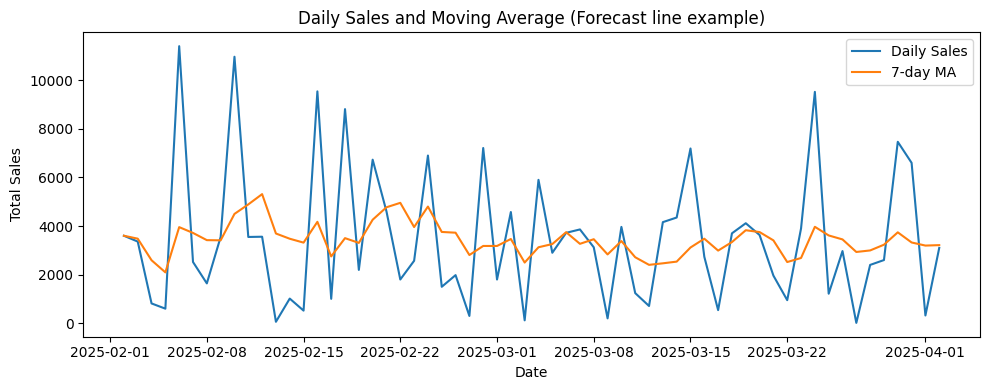

In [12]:
# FORECAST LINES
daily_sales = daily['Total Sales'].asfreq('D').fillna(0)
window = 7
daily_sales_ma = daily_sales.rolling(window=window, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(daily_sales.index, daily_sales, label='Daily Sales')
ax.plot(daily_sales_ma.index, daily_sales_ma, label=f'{window}-day MA')
ax.set_title('Daily Sales and Moving Average (Forecast line example)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend()
plt.tight_layout()
plt.show()

RFM table (sample):


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_sum
Customer Name,,,,,,,,
Emma Clark,1,32,29700,5,5,5,555,15
John Doe,6,26,26870,2,4,5,245,11
Jane Smith,1,29,26385,5,5,4,554,14
Olivia Wilson,4,27,25370,2,4,4,244,10
Michael Brown,7,24,22655,1,3,3,133,7
Daniel Harris,2,23,18945,4,2,3,423,9
Chris White,3,22,18885,4,2,2,422,8
Emily Johnson,8,21,18675,1,1,2,112,4
David Lee,4,24,11865,3,3,1,331,7


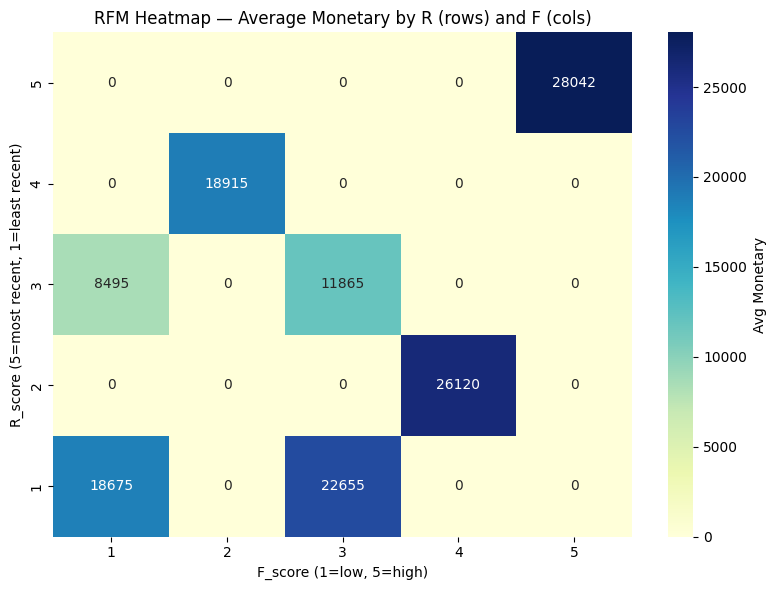

Saved RFM segments to rfm_segments.csv


In [18]:
# RFM robust implementation and heatmap
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')            
df['Total Sales'] = pd.to_numeric(df['Total Sales'], errors='coerce') 

df_rfm_ready = df.dropna(subset=['Date', 'Total Sales']).copy()

if 'Customer Name' in df_rfm_ready.columns and 'Order ID' in df_rfm_ready.columns:
    snapshot_date = df_rfm_ready['Date'].max() + pd.Timedelta(days=1)

    rfm = df_rfm_ready.groupby('Customer Name').agg(
        Recency = ('Date', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('Order ID', 'nunique'),
        Monetary = ('Total Sales', 'sum')
    )

    def make_score(series, n_bins=5, reverse=False):
        bins = min(n_bins, series.nunique())
        if bins <= 1:
            return pd.Series(1, index=series.index)
        ranked = series.rank(method='first')
        
        labels = list(range(1, bins+1))
        if reverse:
            labels = labels[::-1]

        scored = pd.qcut(ranked, q=bins, labels=labels)
        return scored.astype(int)

    rfm['R_score'] = make_score(rfm['Recency'], n_bins=5, reverse=True)
    rfm['F_score'] = make_score(rfm['Frequency'], n_bins=5, reverse=False)
    rfm['M_score'] = make_score(rfm['Monetary'], n_bins=5, reverse=False)

    rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
    rfm['RFM_sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

    print("RFM table (sample):")
    display(rfm.sort_values('Monetary', ascending=False).head(10))

    pivot = rfm.pivot_table(index='R_score', columns='F_score', values='Monetary', aggfunc='mean').fillna(0)

    pivot = pivot.sort_index(ascending=False).sort_index(axis=1, ascending=True)

    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Avg Monetary'})
    plt.title('RFM Heatmap — Average Monetary by R (rows) and F (cols)')
    plt.xlabel('F_score (1=low, 5=high)')
    plt.ylabel('R_score (5=most recent, 1=least recent)')
    plt.tight_layout()
    plt.show()

    rfm.to_csv(r"C:\Users\Admin\Desktop\Amazon\rfm_segments.csv", index=True)
    print("Saved RFM segments to rfm_segments.csv")

else:
    print("No 'Customer Name' or 'Order ID' columns found — skipping RFM.")


In [14]:
# NORMALIZATION & TRANSFORMATIONS
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
numeric_for_scaling = df[['Price','Quantity','Total Sales']].dropna()

if not numeric_for_scaling.empty:
    sscaler = StandardScaler()
    mmscaler = MinMaxScaler()
    rscaler = RobustScaler()
    numeric_standard = sscaler.fit_transform(numeric_for_scaling)
    numeric_minmax = mmscaler.fit_transform(numeric_for_scaling)
    numeric_robust = rscaler.fit_transform(numeric_for_scaling)

    numeric_log = np.log1p(numeric_for_scaling)
    print('Shapes after scaling:', numeric_standard.shape)

    display(pd.DataFrame(numeric_for_scaling).head())
    display(pd.DataFrame(numeric_standard, columns=numeric_for_scaling.columns).head())
    display(pd.DataFrame(numeric_minmax, columns=numeric_for_scaling.columns).head())
    display(pd.DataFrame(numeric_robust, columns=numeric_for_scaling.columns).head())
    display(numeric_log.head())
else:
    print('No numeric rows found for scaling')

Shapes after scaling: (243, 3)


,Price,Quantity,Total Sales
0,60,3,180
1,100,4,400
2,60,2,120
3,60,3,180
4,150,3,450


,Price,Quantity,Total Sales
0,-0.727308,0.130057,-0.648843
1,-0.614943,0.832363,-0.437471
2,-0.727308,-0.572250,-0.706489
3,-0.727308,0.130057,-0.648843
4,-0.474487,0.130057,-0.389432


,Price,Quantity,Total Sales
0,0.037975,0.50,0.041405
1,0.071730,0.75,0.096612
2,0.037975,0.25,0.026349
3,0.037975,0.50,0.041405
4,0.113924,0.50,0.109159


,Price,Quantity,Total Sales
0,-0.195652,0.0,-0.109091
1,-0.108696,0.5,0.090909
2,-0.195652,-0.5,-0.163636
3,-0.195652,0.0,-0.109091
4,0.000000,0.0,0.136364


,Price,Quantity,Total Sales
0,4.110874,1.386294,5.198497
1,4.615121,1.609438,5.993961
2,4.110874,1.098612,4.795791
3,4.110874,1.386294,5.198497
4,5.017280,1.386294,6.111467
